# Spotify charts 

In [1]:
import requests
url = "https://charts.spotify.com/charts/view/citytoptrack-vancouver-weekly/2025-05-01"

res = requests.get(url)

In [2]:
res

<Response [200]>

In [4]:
#!/usr/bin/env python3
"""
Pull a Spotify chart to CSV.

Setup: create tokens.json with the refresh_token from the /api/token response:
    {"refresh_token": "AQD..."}

Usage:
    python charts.py citytoptrack-vancouver-weekly
    python charts.py regional-ca-weekly 2026-07-17 out.csv
"""
import csv
import json
import sys
from pathlib import Path

import requests

CLIENT_ID = "44407c71b3b24071865aaa4fea948a15"
TOKENS = Path("tokens.json")


def access_token():
    rt = json.loads(TOKENS.read_text())["refresh_token"]
    r = requests.post("https://accounts.spotify.com/api/token", data={
        "grant_type": "refresh_token",
        "refresh_token": rt,
        "client_id": CLIENT_ID,
    }, timeout=30)
    r.raise_for_status()
    d = r.json()
    # Spotify rotates refresh tokens on PKCE clients - persist or this works once.
    if d.get("refresh_token"):
        TOKENS.write_text(json.dumps({"refresh_token": d["refresh_token"]}))
    return d["access_token"]


def fetch(alias, date="latest"):
    r = requests.get(
        f"https://charts-spotify-com-service.spotify.com/auth/v0/charts/{alias}/{date}",
        headers={
            "authorization": f"Bearer {access_token()}",
            "app-platform": "Browser",
            "spotify-app-version": "0.0.0.production",
            "accept": "application/json",
        }, timeout=30)
    r.raise_for_status()
    return r.json()


def rows(payload):
    date = payload["displayChart"]["date"]
    for e in payload["entries"]:
        c, t = e["chartEntryData"], e["trackMetadata"]
        yield {
            "date": date,
            "rank": c["currentRank"],
            "previous_rank": c.get("previousRank"),
            "peak_rank": c.get("peakRank"),
            "peak_date": c.get("peakDate"),
            "weeks_on_chart": c.get("appearancesOnChart"),
            "consecutive_weeks": c.get("consecutiveAppearancesOnChart"),
            "entry_rank": c.get("entryRank"),
            "entry_date": c.get("entryDate"),
            "status": c.get("entryStatus"),
            "track": t["trackName"],
            "artists": ", ".join(a["name"] for a in t.get("artists", [])),
            "label": ", ".join(l["name"] for l in t.get("labels", [])),
            "release_date": t.get("releaseDate"),
            "track_id": t["trackUri"].rsplit(":", 1)[-1],
        }


def main():
    alias = "citytoptrack-vancouver-weekly"
    date = "latest"
    out = f"{alias}-{date}.csv"

    data = list(rows(fetch(alias, date)))
    with open(out, "w", newline="", encoding="utf-8") as fh:
        w = csv.DictWriter(fh, fieldnames=list(data[0]))
        w.writeheader()
        w.writerows(data)
    print(f"{len(data)} rows -> {out}")

In [5]:
main()

100 rows -> citytoptrack-vancouver-weekly-latest.csv


# Wikipedia Analytics API

## Daily Page views for different articles

Matplotlib is building the font cache; this may take a moment.


article     Artificial_intelligence  Bitcoin
date                                        
2025-01-01                     9447     7798
2025-01-02                    10777    10397
2025-01-03                    10148    10594
2025-01-04                     9172     9354
2025-01-05                     8865     9327

article  Artificial_intelligence  Bitcoin
count                      365.0    365.0
mean                     10672.0   5535.0
std                       2198.0   1628.0
min                       6726.0   2880.0
25%                       9177.0   4476.0
50%                      10468.0   5146.0
75%                      11732.0   6032.0
max                      21977.0  12863.0


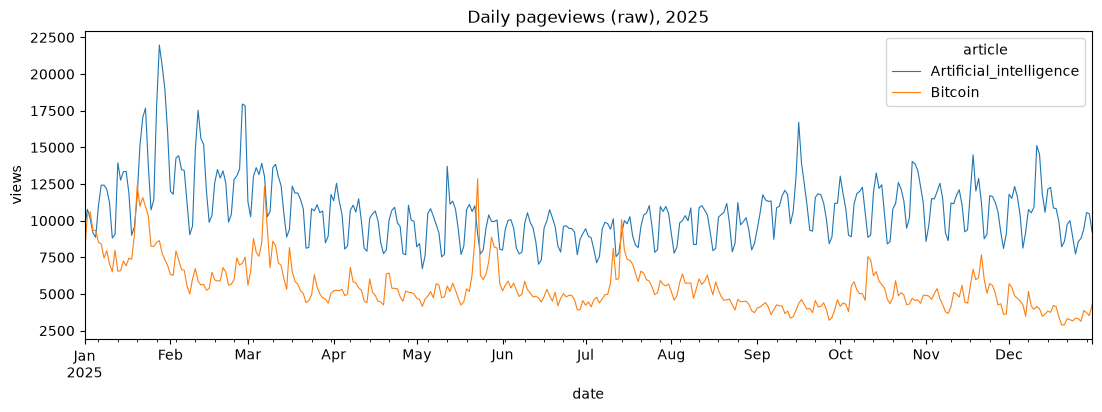

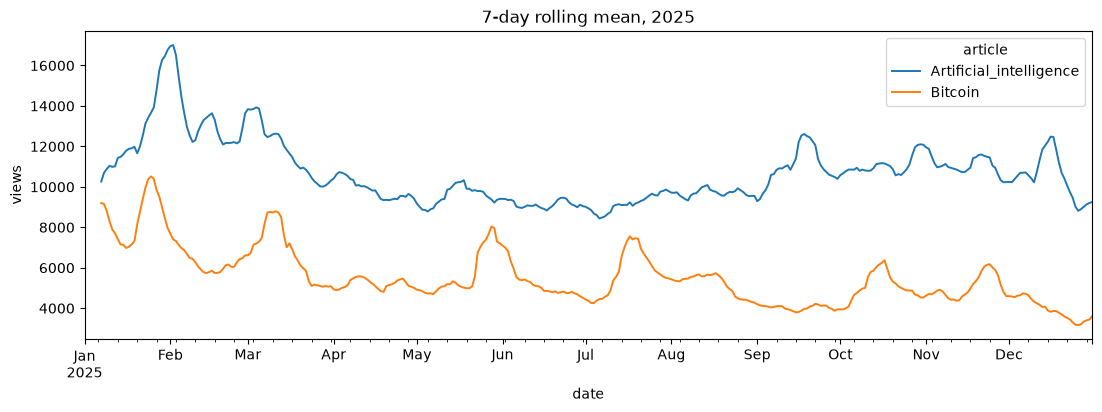

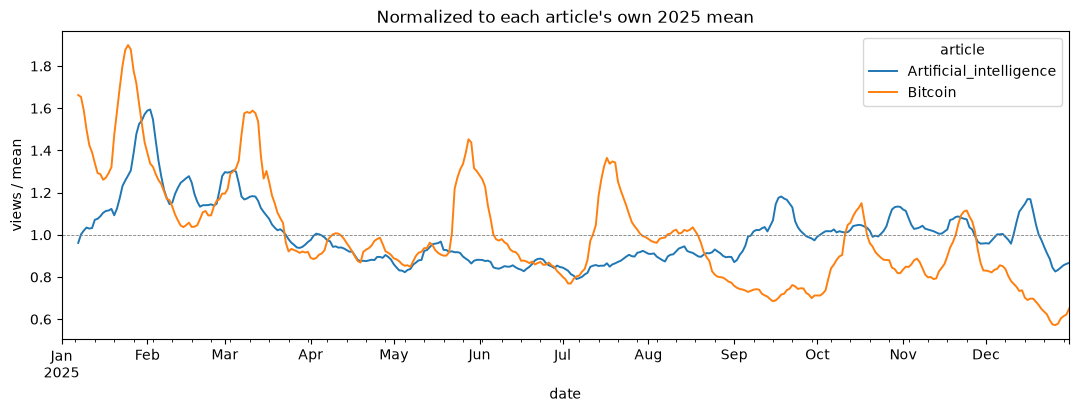


Top 5 days — Artificial_intelligence
date
2025-01-28    21977
2025-01-29    20590
2025-01-30    18946
2025-02-27    17952
2025-02-28    17832
Name: Artificial_intelligence, dtype: int64

Top 5 days — Bitcoin
date
2025-05-23    12863
2025-01-20    12398
2025-03-07    12355
2025-01-22    11579
2025-01-21    10982
Name: Bitcoin, dtype: int64


In [8]:
# Example 1 — Daily pageviews for two articles, en.wikipedia, all of 2025
# Endpoint: /metrics/pageviews/per-article/{project}/{access}/{agent}/{article}/{granularity}/{start}/{end}

import requests
import pandas as pd
import matplotlib.pyplot as plt

# Wikimedia asks that you identify yourself. Put a real contact here.
HEADERS = {"User-Agent": "zeitgeist-test (you@example.com)"}

BASE = "https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article"
PROJECT = "en.wikipedia.org"
ARTICLES = ["Bitcoin", "Artificial_intelligence"]
START, END = "20250101", "20251231"

# agent=user strips crawlers/bots. Without it the series is badly polluted.
AGENT = "user"
ACCESS = "all-access"  # try "desktop" / "mobile-web" later to see the split

frames = []
for article in ARTICLES:
    url = f"{BASE}/{PROJECT}/{ACCESS}/{AGENT}/{article}/daily/{START}/{END}"
    resp = requests.get(url, headers=HEADERS)
    resp.raise_for_status()
    df = pd.DataFrame(resp.json()["items"])
    frames.append(df[["timestamp", "article", "views"]])

daily = pd.concat(frames, ignore_index=True)
daily["date"] = pd.to_datetime(daily["timestamp"], format="%Y%m%d%H")

# One column per article, indexed by date
wide = daily.pivot(index="date", columns="article", values="views")

print(wide.head())
print()
print(wide.describe().round(0))

# ---- Raw daily ----
wide.plot(figsize=(13, 4), linewidth=0.8, title="Daily pageviews (raw), 2025")
plt.ylabel("views")
plt.show()

# ---- 7-day rolling mean ----
# The AI "slow climb" is invisible under daily noise; the smoothed line is
# where you'd actually see drift vs. spike.
wide.rolling(7).mean().plot(
    figsize=(13, 4), linewidth=1.4, title="7-day rolling mean, 2025"
)
plt.ylabel("views")
plt.show()

# ---- Normalized, so the two are comparable despite different scales ----
(wide / wide.mean()).rolling(7).mean().plot(
    figsize=(13, 4), linewidth=1.4, title="Normalized to each article's own 2025 mean"
)
plt.ylabel("views / mean")
plt.axhline(1.0, color="grey", linewidth=0.6, linestyle="--")
plt.show()

# ---- Biggest single-day spikes: sanity-check against real events ----
for article in wide.columns:
    print(f"\nTop 5 days — {article}")
    print(wide[article].nlargest(5))

## Top pages per country

In [12]:
HEADERS = {"User-Agent": "zeitgeist-test (you@example.com)"}
ROOT = "https://wikimedia.org/api/rest_v1/metrics/pageviews/top-per-country"

In [15]:
# Example 2 (v3) — Top articles per country for 2025 (US / CA / GB)
#
# Confirmed endpoint shape:
#   /metrics/pageviews/top-per-country/{COUNTRY}/{access}/{year}/{month}/{day}
# Notes established by probing:
#   - daily only; "all-days" returns 400, so there is no monthly aggregate
#   - returns 1000 articles per country-day
#   - counts are views_ceil, rounded up to the nearest 100
#   - country code must be uppercase; no agent parameter
#   - data available from 2021-01-01

import time
import datetime as dt
import requests
import pandas as pd

HEADERS = {"User-Agent": "zeitgeist-test (you@example.com)"}
ROOT = "https://wikimedia.org/api/rest_v1/metrics/pageviews/top-per-country"

COUNTRIES = {"US": "United States", "CA": "Canada", "GB": "United Kingdom"}
YEAR = 2025
TOP_N = 50          # "appeared in the top N that day" — 50 of 1000, not 10 of 50
STRIDE = 8          # sample every 8th day: 46 days/yr, rotates through weekdays
                    # set STRIDE = 1 for the full year (1095 requests, ~20 min)


# ============================================================ CELL 1: fetch
start = dt.date(YEAR, 1, 1)
days = [start + dt.timedelta(days=i) for i in range(0, 365, STRIDE)]
print(f"{len(days)} days x {len(COUNTRIES)} countries "
      f"= {len(days) * len(COUNTRIES)} requests")

rows = []
for code in COUNTRIES:
    for i, d in enumerate(days):
        url = f"{ROOT}/{code}/all-access/{d.year}/{d.month:02d}/{d.day:02d}"
        resp = requests.get(url, headers=HEADERS)
        if resp.status_code != 200:
            print(f"  skipped {code} {d}: HTTP {resp.status_code}")
            continue
        for art in resp.json()["items"][0]["articles"]:
            rows.append({
                "country": code,
                "date": d,
                "article": art["article"],
                "project": art["project"],
                "rank": int(art["rank"]),
                "views": int(art["views_ceil"]),
            })
        time.sleep(0.1)
    print(f"  {code} done")

raw = pd.DataFrame(rows)
assert not raw.empty, "No data fetched."
print(f"\n{len(raw):,} rows, {raw['date'].nunique()} distinct days")

# Confirms country != language (expect fr.wikipedia to show up for CA):
print("\ntop projects per country:")
print(raw.groupby("country")["project"].value_counts().groupby(level=0).head(4))


# ========================================================== CELL 2: clean
import re

# --- Filter 1: main pages -------------------------------------------------
# Every language edition has its own main-page title, so a hardcoded list is
# unmaintainable. Wikidata item Q5296 is "Main Page"; its sitelinks give the
# canonical title on every wiki in a single request.
def wikidata_main_page_titles():
    r = requests.get(
        "https://www.wikidata.org/w/api.php",
        params={"action": "wbgetentities", "ids": "Q5296",
                "props": "sitelinks", "format": "json"},
        headers=HEADERS,
    )
    r.raise_for_status()
    links = r.json()["entities"]["Q5296"]["sitelinks"]
    return {info["title"].replace(" ", "_") for info in links.values()}

MAIN_PAGES = wikidata_main_page_titles()
print(f"\n{len(MAIN_PAGES)} main-page titles from Wikidata")

# --- Filter 2: namespace pages -------------------------------------------
# Namespaces are localized too (Special:Search, Ihü_kárírí:Search, Spesial:Søk),
# so prefix lists also fail. Heuristic: a namespace prefix is a colon NOT
# followed by an underscore, with no underscore before it. Real article titles
# with colons look like "Star_Trek:_The_Next_Generation" — colon then
# underscore — so they survive.
NAMESPACE_RE = re.compile(r"^[^:_]+:[^_]")

is_main = raw["article"].isin(MAIN_PAGES)
is_ns = raw["article"].str.match(NAMESPACE_RE)
is_junk = raw["article"].isin({"-", "Undefined", "Null"})

clean = raw[~(is_main | is_ns | is_junk)].copy()
clean["key"] = clean["article"] + "  [" + clean["project"] + "]"
print(f"{len(clean):,} rows after filtering (from {len(raw):,})")

# --- Verify the heuristic didn't eat anything real ------------------------
# Always eyeball this. If a legitimate article appears here, tighten the regex.
removed = raw[~raw.index.isin(clean.index)]
print("\nmost-viewed titles removed (check for false positives):")
print(removed.groupby("article")["views"].sum().nlargest(20).to_string())


# ====================================================== CELL 3: aggregate
# Primary ranking is a plain sum of views. With 1000-article lists and
# hundred-rounded counts, that is sound for anything near the top.
#
# peak_share = biggest single day / total. Near 1.0 means one-day news spike;
# near 1/days_present means steady year-round interest. That split is the
# actual signal of interest, not a correction for a broken sum.
agg = (
    clean.groupby(["country", "key"])
    .agg(total_views=("views", "sum"),
         days_present=("date", "nunique"),
         peak_day=("views", "max"),
         best_rank=("rank", "min"),
         days_in_top_n=("rank", lambda s: (s <= TOP_N).sum()))
    .reset_index()
)
agg["peak_share"] = (agg["peak_day"] / agg["total_views"]).round(2)


# ========================================================= CELL 4: report
n_days = clean["date"].nunique()
for code, name in COUNTRIES.items():
    sub = agg[agg["country"] == code]
    if sub.empty:
        continue

    print("=" * 78)
    print(f"{name} ({code}) — {YEAR}, sampled {n_days} days")

    print("\n  Top 5 by total views")
    print(sub.nlargest(5, "total_views")[
        ["key", "total_views", "days_present", "peak_share", "best_rank"]
    ].to_string(index=False))

    # Steady = present on most sampled days AND not spike-dominated.
    steady = sub[(sub["days_present"] >= 0.8 * n_days) & (sub["peak_share"] < 0.15)]
    print(f"\n  Top 5 steady (on >=80% of days, no dominant spike)")
    print(steady.nlargest(5, "total_views")[
        ["key", "total_views", "days_present", "peak_share"]
    ].to_string(index=False) if not steady.empty else "    none")

    # Spike-driven = most of the year's views landed on one day.
    spiky = sub[(sub["total_views"] > sub["total_views"].quantile(0.99))
                & (sub["peak_share"] > 0.5)]
    print(f"\n  Spike-driven (>50% of views on a single day)")
    print(spiky.nlargest(5, "peak_share")[
        ["key", "total_views", "days_present", "peak_share"]
    ].to_string(index=False) if not spiky.empty else "    none")
    print()


# =================================================== CELL 5: cross-country
# Shared vs. distinctive — the "does zeitgeist differ by region" question.
top50 = {c: set(agg[agg["country"] == c].nlargest(50, "total_views")["key"])
         for c in COUNTRIES}
shared = set.intersection(*top50.values())

print("=" * 78)
print(f"In all three countries' top 50: {len(shared)}")
for k in sorted(shared)[:15]:
    print("   ", k)

for c in COUNTRIES:
    unique = top50[c] - set.union(*[top50[o] for o in COUNTRIES if o != c])
    print(f"\nOnly in {c}'s top 50 ({len(unique)}):")
    for k in sorted(unique)[:10]:
        print("   ", k)

46 days x 3 countries = 138 requests
  US done
  CA done
  GB done

103,807 rows, 46 distinct days

top projects per country:
country  project          
CA       en.wikipedia         12759
         fr.wikipedia           467
         pl.wikipedia            81
         commons.wikimedia       61
GB       en.wikipedia         43518
         en.wiktionary           92
         commons.wikimedia       83
         ru.wikipedia            62
US       en.wikipedia         44320
         commons.wikimedia      207
         es.wikipedia           111
         zh.wikipedia           110
Name: count, dtype: int64

499 main-page titles from Wikidata
100,491 rows after filtering (from 103,807)

most-viewed titles removed (check for false positives):
article
Main_Page                                                  114360200
Special:Search                                              36495900
Wikipedia:首页                                                 5649900
Wikipédia:Accueil_principal          